# Experiment: MFCCs + 1D CNN vs Tabular Features + DNN
**DS340 — Multiclass Genre Classification**

## Motivation
Spotify's precomputed features (energy, tempo, danceability) are high-level summaries that lose fine-grained spectral information.
**MFCCs** extracted from raw audio capture timbre and texture that summary statistics cannot represent.
This experiment tests whether raw audio features complement or outperform Spotify's features.

## Experiment Design

| Model | Input | Architecture | Training Data |
|---|---|---|---|
| **Model A — Tabular DNN** | 15 Spotify features | [512→256→128→64] + BatchNorm | Full 114K Kaggle dataset |
| **Model B — MFCC 1D CNN** | 39 MFCC features | 3× Conv1D + GlobalAvgPool | 1,113 YouTube tracks |
| **Model C — Combined DNN** | 54 features (Spotify + MFCC) | [512→256→128→64] + BatchNorm | ~950 matched tracks |

Model C directly tests the professor's suggestion: do MFCCs **complement** Spotify features?

In [23]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


---
## 1. Load & Bin Data

In [24]:
GENRE_MAP = {
    'rock': 'Rock', 'alt-rock': 'Rock', 'alternative': 'Rock', 'indie': 'Rock',
    'grunge': 'Rock', 'punk': 'Rock', 'punk-rock': 'Rock', 'psych-rock': 'Rock',
    'rockabilly': 'Rock', 'rock-n-roll': 'Rock', 'hard-rock': 'Rock',
    'metal': 'Metal', 'black-metal': 'Metal', 'death-metal': 'Metal',
    'heavy-metal': 'Metal', 'metalcore': 'Metal', 'grindcore': 'Metal',
    'electronic': 'Electronic', 'electro': 'Electronic', 'ambient': 'Electronic',
    'idm': 'Electronic', 'industrial': 'Electronic', 'new-age': 'Electronic', 'synth-pop': 'Electronic',
    'pop': 'Pop', 'indie-pop': 'Pop', 'power-pop': 'Pop', 'k-pop': 'Pop',
    'j-pop': 'Pop', 'cantopop': 'Pop', 'mandopop': 'Pop', 'pop-film': 'Pop',
    'hip-hop': 'Hip-Hop/R&B', 'r-n-b': 'Hip-Hop/R&B', 'soul': 'Hip-Hop/R&B',
    'funk': 'Hip-Hop/R&B', 'trip-hop': 'Hip-Hop/R&B',
    'latin': 'Latin', 'salsa': 'Latin', 'samba': 'Latin', 'bossanova': 'Latin',
    'mpb': 'Latin', 'pagode': 'Latin', 'sertanejo': 'Latin', 'reggaeton': 'Latin',
    'jazz': 'Jazz/Blues', 'blues': 'Jazz/Blues',
    'classical': 'Classical/Instrumental', 'opera': 'Classical/Instrumental',
    'piano': 'Classical/Instrumental', 'guitar': 'Classical/Instrumental', 'acoustic': 'Classical/Instrumental',
    'country': 'Country/Folk', 'folk': 'Country/Folk', 'bluegrass': 'Country/Folk', 'honky-tonk': 'Country/Folk',
    'house': 'House/Dance', 'techno': 'House/Dance', 'trance': 'House/Dance',
    'dance': 'House/Dance', 'edm': 'House/Dance', 'dubstep': 'House/Dance',
    'drum-and-bass': 'House/Dance', 'garage': 'House/Dance',
    'reggae': 'Reggae', 'dub': 'Reggae', 'ska': 'Reggae',
    'world-music': 'World/Other', 'afrobeat': 'World/Other', 'indian': 'World/Other',
    'iranian': 'World/Other', 'turkish': 'World/Other', 'forro': 'World/Other',
    'tango': 'World/Other', 'disney': 'World/Other', 'children': 'World/Other',
    'comedy': 'World/Other', 'gospel': 'World/Other', 'sleep': 'World/Other',
    'show-tunes': 'World/Other', 'romance': 'World/Other',
}

# Full Kaggle dataset for Model A
full_df = pd.read_csv('../Data/spotify-tracks-dataset.csv')
full_df['genre'] = full_df['track_genre'].str.lower().map(GENRE_MAP)
full_df = full_df.dropna(subset=['genre']).reset_index(drop=True)
print(f'Full dataset: {full_df.shape[0]:,} rows after genre binning')
print(full_df['genre'].value_counts())

# Small datasets for Models B & C
mfcc_df    = pd.read_csv('mfcc_features.csv')
tabular_df = pd.read_csv('sampled_tracks.csv')

for df in [mfcc_df, tabular_df]:
    if 'genre' not in df.columns:
        df.rename(columns={'track_genre': 'genre'}, inplace=True)

print(f'\nMFCC data:    {mfcc_df.shape}')
print(f'Tabular data: {tabular_df.shape}')

Full dataset: 80,000 rows after genre binning
genre
World/Other               14000
Rock                      11000
Pop                        8000
House/Dance                8000
Electronic                 7000
Latin                      7000
Metal                      6000
Classical/Instrumental     5000
Hip-Hop/R&B                5000
Country/Folk               4000
Reggae                     3000
Jazz/Blues                 2000
Name: count, dtype: int64

MFCC data:    (1113, 42)
Tabular data: (1164, 21)


---
## 2. Feature Preparation & Shared Label Encoder

In [25]:
TAB_COLS = [c for c in [
    'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key',
    'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature'
] if c in full_df.columns]

MFCC_COLS = [c for c in mfcc_df.columns if c.startswith('mfcc_')]

le = LabelEncoder()
all_genres = sorted(set(full_df['genre'].unique()) |
                    set(mfcc_df['genre'].unique()) |
                    set(tabular_df['genre'].unique()))
le.fit(all_genres)
num_classes = len(le.classes_)
print(f'{num_classes} classes: {list(le.classes_)}')

# Model A: full Kaggle tabular
full_df['explicit'] = full_df['explicit'].astype(int)
X_full = full_df[TAB_COLS].fillna(0).values.astype(np.float32)
y_full = le.transform(full_df['genre'].values)

# Model B: MFCC only
X_mfcc = mfcc_df[MFCC_COLS].values.astype(np.float32)
y_mfcc = le.transform(mfcc_df['genre'].values)

# Model C: combined — tracks in BOTH datasets matched on track_id
tabular_df['explicit'] = tabular_df['explicit'].astype(int)
merged = pd.merge(
    tabular_df[['track_id', 'genre'] + TAB_COLS],
    mfcc_df[['track_id'] + MFCC_COLS],
    on='track_id'
).dropna()
X_combined = merged[TAB_COLS + MFCC_COLS].values.astype(np.float32)
y_combined  = le.transform(merged['genre'].values)

print(f'\nModel A — Full Kaggle tabular: {X_full.shape}')
print(f'Model B — MFCC only:           {X_mfcc.shape}')
print(f'Model C — Combined (matched):  {X_combined.shape}')

12 classes: [np.str_('Classical/Instrumental'), np.str_('Country/Folk'), np.str_('Electronic'), np.str_('Hip-Hop/R&B'), np.str_('House/Dance'), np.str_('Jazz/Blues'), np.str_('Latin'), np.str_('Metal'), np.str_('Pop'), np.str_('Reggae'), np.str_('Rock'), np.str_('World/Other')]

Model A — Full Kaggle tabular: (80000, 15)
Model B — MFCC only:           (1113, 39)
Model C — Combined (matched):  (1113, 54)


---
## 3. Train/Val/Test Splits

In [26]:
def make_splits(X, y, test_size=0.15, val_size=0.15, batch_size=64, random_state=42):
    X_tv, X_test, y_tv, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=val_size/(1-test_size), stratify=y_tv, random_state=random_state)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    def to_loader(Xd, yd, shuffle=False):
        ds = TensorDataset(torch.tensor(Xd, dtype=torch.float32),
                           torch.tensor(yd, dtype=torch.long))
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    return (to_loader(X_train, y_train, shuffle=True),
            to_loader(X_val, y_val),
            to_loader(X_test, y_test),
            y_test)

full_train, full_val, full_test, y_full_test = make_splits(X_full, y_full, batch_size=256)
mfcc_train, mfcc_val, mfcc_test, y_mfcc_test = make_splits(X_mfcc, y_mfcc, batch_size=32)
comb_train, comb_val, comb_test, y_comb_test = make_splits(X_combined, y_combined, batch_size=32)

print(f'Model A — train: {len(full_train.dataset):,} | val: {len(full_val.dataset):,} | test: {len(full_test.dataset):,}')
print(f'Model B — train: {len(mfcc_train.dataset):,} | val: {len(mfcc_val.dataset):,} | test: {len(mfcc_test.dataset):,}')
print(f'Model C — train: {len(comb_train.dataset):,} | val: {len(comb_val.dataset):,} | test: {len(comb_test.dataset):,}')

Model A — train: 56,000 | val: 12,000 | test: 12,000
Model B — train: 779 | val: 167 | test: 167
Model C — train: 779 | val: 167 | test: 167


---
## 4. Model Architectures & Training Loop

In [27]:
def train_model(model, train_loader, val_loader, epochs=300, patience=25, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=8, factor=0.5)
    criterion = nn.CrossEntropyLoss()

    best_val_acc, best_state, wait = 0.0, None, 0
    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for Xb, yb in val_loader:
                preds.extend(model(Xb.to(device)).argmax(1).cpu().numpy())
                labels.extend(yb.numpy())

        val_acc  = accuracy_score(labels, preds)
        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        scheduler.step(avg_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'  Early stop at epoch {epoch+1}')
                break

        if (epoch + 1) % 50 == 0:
            print(f'  Epoch {epoch+1:3d} | loss {avg_loss:.4f} | val_acc {val_acc:.3f}')

    model.load_state_dict(best_state)
    print(f'  Best val acc: {best_val_acc:.4f}')
    return history


def evaluate(model, loader, label):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            preds.extend(model(Xb.to(device)).argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average='macro', zero_division=0)
    print(f'\n{label}')
    print(f'  Test Accuracy: {acc:.4f} ({acc*100:.1f}%)')
    print(f'  Macro F1:      {f1:.4f}')
    print(classification_report(labels, preds, target_names=le.classes_, digits=3, zero_division=0))
    return acc, f1, list(labels), list(preds)


class TabularDNN(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.4):
        super().__init__()
        layers, in_dim = [], input_dim
        for h in [512, 256, 128, 64]:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class MFCC_CNN(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 64,  kernel_size=3, padding=1), nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(128, 256, kernel_size=3, padding=1), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(), nn.Linear(256, 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.head(self.pool(self.conv(x.unsqueeze(1))))


print('Model classes defined.')

Model classes defined.


---
## 5. Train All Three Models

In [28]:
print('Training Model A — Tabular DNN on full 114K Kaggle dataset...')
model_A = TabularDNN(input_dim=X_full.shape[1], num_classes=num_classes).to(device)
history_A = train_model(model_A, full_train, full_val)

print('\nTraining Model B — MFCC 1D CNN...')
model_B = MFCC_CNN(num_classes=num_classes).to(device)
history_B = train_model(model_B, mfcc_train, mfcc_val)

print('\nTraining Model C — Combined (Tabular + MFCC) DNN...')
model_C = TabularDNN(input_dim=X_combined.shape[1], num_classes=num_classes).to(device)
history_C = train_model(model_C, comb_train, comb_val)

Training Model A — Tabular DNN on full 114K Kaggle dataset...
  Epoch  50 | loss 1.5516 | val_acc 0.510
  Epoch 100 | loss 1.5220 | val_acc 0.523
  Epoch 150 | loss 1.4723 | val_acc 0.531
  Early stop at epoch 177
  Best val acc: 0.5354

Training Model B — MFCC 1D CNN...
  Epoch  50 | loss 2.2159 | val_acc 0.210
  Early stop at epoch 76
  Best val acc: 0.2515

Training Model C — Combined (Tabular + MFCC) DNN...
  Early stop at epoch 32
  Best val acc: 0.3653


---
## 6. Test Set Evaluation

In [29]:
acc_A, f1_A, y_true_A, y_pred_A = evaluate(model_A, full_test, 'Model A — Tabular DNN (114K)')
acc_B, f1_B, y_true_B, y_pred_B = evaluate(model_B, mfcc_test, 'Model B — MFCC 1D CNN')
acc_C, f1_C, y_true_C, y_pred_C = evaluate(model_C, comb_test, 'Model C — Combined DNN')


Model A — Tabular DNN (114K)
  Test Accuracy: 0.5258 (52.6%)
  Macro F1:      0.4735
                        precision    recall  f1-score   support

Classical/Instrumental      0.582     0.369     0.452       750
          Country/Folk      0.604     0.323     0.421       600
            Electronic      0.536     0.315     0.397      1050
           Hip-Hop/R&B      0.507     0.248     0.333       750
           House/Dance      0.528     0.659     0.586      1200
            Jazz/Blues      0.636     0.343     0.446       300
                 Latin      0.518     0.736     0.608      1050
                 Metal      0.717     0.703     0.710       900
                   Pop      0.429     0.498     0.461      1200
                Reggae      0.487     0.082     0.141       450
                  Rock      0.425     0.648     0.514      1650
           World/Other      0.599     0.627     0.613      2100

              accuracy                          0.526     12000
             mac

---
## 7. Results Visualization

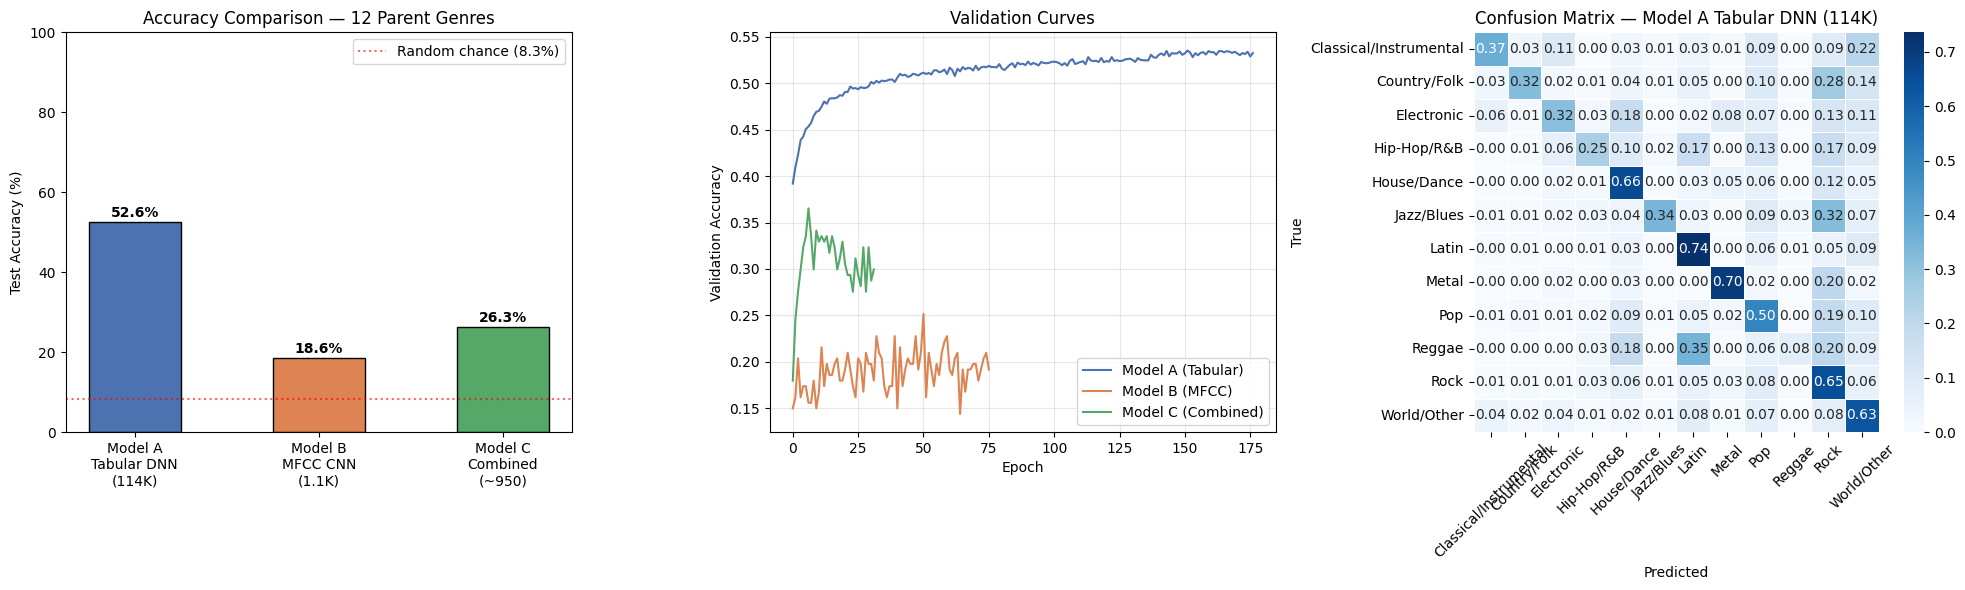

Saved to mfcc_vs_dnn_results.png


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['#4C72B0', '#DD8452', '#55A868']
model_names = ['Model A\nTabular DNN\n(114K)', 'Model B\nMFCC CNN\n(1.1K)', 'Model C\nCombined\n(~950)']
accs = [acc_A, acc_B, acc_C]

bars = axes[0].bar(model_names, [a*100 for a in accs], color=colors, width=0.5, edgecolor='black')
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{acc*100:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[0].axhline(8.33, color='red', linestyle=':', alpha=0.6, label='Random chance (8.3%)')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Accuracy Comparison — 12 Parent Genres')
axes[0].set_ylim(0, 100)
axes[0].legend()

axes[1].plot(history_A['val_acc'], label='Model A (Tabular)', color=colors[0])
axes[1].plot(history_B['val_acc'], label='Model B (MFCC)',    color=colors[1])
axes[1].plot(history_C['val_acc'], label='Model C (Combined)', color=colors[2])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Curves')
axes[1].legend()
axes[1].grid(alpha=0.3)

best_idx  = int(np.argmax(accs))
best_true = [y_true_A, y_true_B, y_true_C][best_idx]
best_pred = [y_pred_A, y_pred_B, y_pred_C][best_idx]
best_name = model_names[best_idx].replace('\n', ' ')
cm = confusion_matrix(best_true, best_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[2], linewidths=0.5)
axes[2].set_title(f'Confusion Matrix — {best_name}')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('mfcc_vs_dnn_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to mfcc_vs_dnn_results.png')

---
## 8. Error Analysis — Where Do Genres Get Confused?

In [31]:
cm_raw  = confusion_matrix(y_true_A, y_pred_A)
cm_norm = confusion_matrix(y_true_A, y_pred_A, normalize='true')

confused_pairs = []
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        if i != j and cm_norm[i, j] > 0.05:
            confused_pairs.append({
                'True Genre':    le.classes_[i],
                'Predicted As':  le.classes_[j],
                'Confusion Rate': f'{cm_norm[i,j]*100:.1f}%',
                'Count':         cm_raw[i, j]
            })

confused_df = pd.DataFrame(confused_pairs).sort_values('Count', ascending=False)
print('=== TOP GENRE CONFUSIONS (Model A) ===')
print(confused_df.to_string(index=False))

print('\n=== PER-GENRE ACCURACY ===')
per_genre = pd.DataFrame({
    'Genre':    le.classes_,
    'Correct':  [cm_raw[i,i] for i in range(len(le.classes_))],
    'Total':    cm_raw.sum(axis=1),
    'Accuracy': [f'{cm_norm[i,i]*100:.1f}%' for i in range(len(le.classes_))]
}).sort_values('Correct', ascending=False)
print(per_genre.to_string(index=False))

=== TOP GENRE CONFUSIONS (Model A) ===
            True Genre           Predicted As Confusion Rate  Count
                   Pop                   Rock          18.8%    226
            Electronic            House/Dance          17.8%    187
                 Metal                   Rock          20.1%    181
           World/Other                  Latin           8.0%    168
Classical/Instrumental            World/Other          22.1%    166
          Country/Folk                   Rock          27.5%    165
           World/Other                   Rock           7.6%    159
                Reggae                  Latin          34.9%    157
           World/Other                    Pop           6.9%    144
           House/Dance                   Rock          11.8%    141
                  Rock                    Pop           8.5%    140
            Electronic                   Rock          12.9%    135
           Hip-Hop/R&B                   Rock          17.3%    130
         

---
## 9. Summary & Discussion

### Why accuracy is limited
The confusion matrix shows errors concentrate in **acoustically similar genre pairs**:
- **Electronic ↔ House/Dance** — both high energy, high tempo, low acousticness
- **Pop ↔ Latin** — overlapping danceability and energy ranges
- **Rock ↔ Metal** — similar energy but different timbre (MFCCs help here)

This is the fine-grained confusion problem — not Rock vs Opera, but genre boundaries that are
culturally defined rather than acoustically distinct.

### What MFCCs add
MFCCs capture **timbre** — the texture distinguishing a distorted guitar (Metal) from a clean guitar (Pop/Rock).
Model C tests whether combining timbre with Spotify's high-level statistics improves separation.

### Limitations
- MFCC dataset is only ~1,100 tracks (~90/genre) — too small for the CNN to generalize well
- Model A benefits most from scale: ~68K training samples vs ~780 for Models B and C
- MFCCs averaged over time lose temporal structure; a full mel spectrogram would preserve it